In [4]:
pip install fastf1

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
os.makedirs('f1_cache', exist_ok=True)

In [6]:
### importing the dataset 
import fastf1
import pandas as pd
import matplotlib.pyplot as plt

fastf1.Cache.enable_cache('f1_cache')

# Load 2023 Australian GP 
session = fastf1.get_session(2023, 'Australia', 'R')
session.event['EventName']




'Australian Grand Prix'

In [7]:
### load the data
session.load()
laps = session.laps
laps.head

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '44', '14', '18', '11', '4', '27', '81', '24', '22', '77', '55', '10', '31', '21', '2', '20', '63', '23', '16']


<bound method NDFrame.head of                        Time Driver DriverNumber                LapTime  \
0    0 days 01:03:58.671000    VER            1 0 days 00:01:41.571000   
1    0 days 01:06:10.776000    VER            1 0 days 00:02:12.105000   
2    0 days 01:08:21.433000    VER            1 0 days 00:02:10.657000   
3    0 days 01:09:44.824000    VER            1 0 days 00:01:23.391000   
4    0 days 01:11:07.928000    VER            1 0 days 00:01:23.104000   
...                     ...    ...          ...                    ...   
998  0 days 02:39:23.012000    PIA           81 0 days 00:02:02.932000   
999  0 days 02:55:41.516000    PIA           81                    NaT   
1000 0 days 02:59:02.357000    PIA           81                    NaT   
1001 0 days 03:32:22.694000    PIA           81                    NaT   
1002 0 days 03:35:00.864000    PIA           81                    NaT   

      LapNumber  Stint             PitOutTime              PitInTime  \
0        

In [8]:
laps_df = pd.DataFrame(laps)
laps_df.head(5)


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:03:58.671000,VER,1,0 days 00:01:41.571000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:18.707000,...,True,Red Bull Racing,0 days 01:02:16.863000,2023-04-02 05:03:18.685,124,3.0,False,,False,False
1,0 days 01:06:10.776000,VER,1,0 days 00:02:12.105000,2.0,1.0,NaT,NaT,0 days 00:00:48.846000,0 days 00:00:31.614000,...,True,Red Bull Racing,0 days 01:03:58.671000,2023-04-02 05:05:00.493,4,3.0,False,,False,False
2,0 days 01:08:21.433000,VER,1,0 days 00:02:10.657000,3.0,1.0,NaT,NaT,0 days 00:00:46.836000,0 days 00:00:29.178000,...,True,Red Bull Racing,0 days 01:06:10.776000,2023-04-02 05:07:12.598,41,3.0,False,,False,False
3,0 days 01:09:44.824000,VER,1,0 days 00:01:23.391000,4.0,1.0,NaT,NaT,0 days 00:00:28.900000,0 days 00:00:18.326000,...,True,Red Bull Racing,0 days 01:08:21.433000,2023-04-02 05:09:23.255,1,3.0,False,,False,True
4,0 days 01:11:07.928000,VER,1,0 days 00:01:23.104000,5.0,1.0,NaT,NaT,0 days 00:00:28.935000,0 days 00:00:18.347000,...,True,Red Bull Racing,0 days 01:09:44.824000,2023-04-02 05:10:46.646,1,3.0,False,,False,True


In [9]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [10]:
print(laps_df.columns.tolist())

['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


In [11]:
print(laps_df.shape)
print(laps.dtypes)

(1003, 31)
Time                  timedelta64[ns]
Driver                         object
DriverNumber                   object
LapTime               timedelta64[ns]
LapNumber                     float64
Stint                         float64
PitOutTime            timedelta64[ns]
PitInTime             timedelta64[ns]
Sector1Time           timedelta64[ns]
Sector2Time           timedelta64[ns]
Sector3Time           timedelta64[ns]
Sector1SessionTime    timedelta64[ns]
Sector2SessionTime    timedelta64[ns]
Sector3SessionTime    timedelta64[ns]
SpeedI1                       float64
SpeedI2                       float64
SpeedFL                       float64
SpeedST                       float64
IsPersonalBest                 object
Compound                       object
TyreLife                      float64
FreshTyre                        bool
Team                           object
LapStartTime          timedelta64[ns]
LapStartDate           datetime64[ns]
TrackStatus                    object
P

In [12]:
laps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Time                1003 non-null   timedelta64[ns]
 1   Driver              1003 non-null   object         
 2   DriverNumber        1003 non-null   object         
 3   LapTime             901 non-null    timedelta64[ns]
 4   LapNumber           1003 non-null   float64        
 5   Stint               1003 non-null   float64        
 6   PitOutTime          67 non-null     timedelta64[ns]
 7   PitInTime           65 non-null     timedelta64[ns]
 8   Sector1Time         968 non-null    timedelta64[ns]
 9   Sector2Time         995 non-null    timedelta64[ns]
 10  Sector3Time         932 non-null    timedelta64[ns]
 11  Sector1SessionTime  966 non-null    timedelta64[ns]
 12  Sector2SessionTime  995 non-null    timedelta64[ns]
 13  Sector3SessionTime  932 non-null 

In [13]:
laps_df.isnull().sum()

Time                    0
Driver                  0
DriverNumber            0
LapTime               102
LapNumber               0
Stint                   0
PitOutTime            936
PitInTime             938
Sector1Time            35
Sector2Time             8
Sector3Time            71
Sector1SessionTime     37
Sector2SessionTime      8
Sector3SessionTime     71
SpeedI1                 8
SpeedI2                 8
SpeedFL                73
SpeedST                 8
IsPersonalBest          7
Compound                0
TyreLife                0
FreshTyre               0
Team                    0
LapStartTime            0
LapStartDate            7
TrackStatus             0
Position                8
Deleted                 0
DeletedReason           7
FastF1Generated         0
IsAccurate              0
dtype: int64

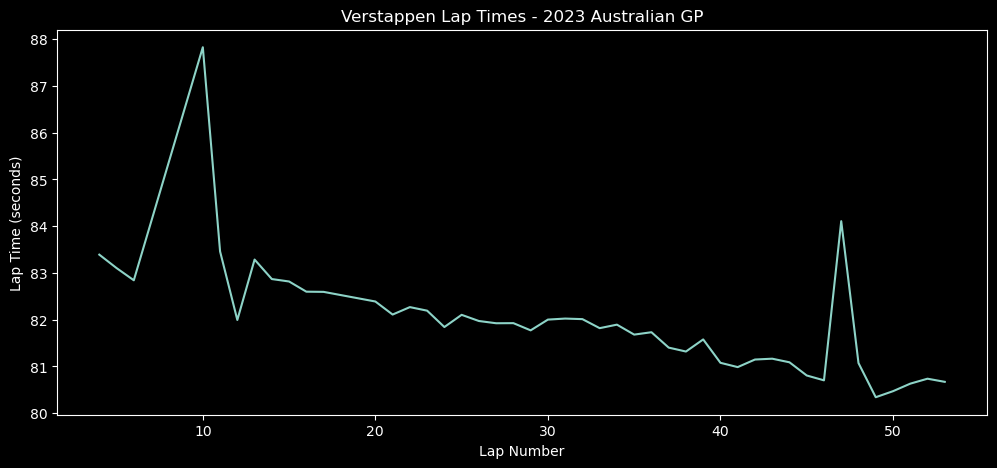

In [14]:
# Convert LapTime to seconds for easier plotting
laps_df['LapTimeSeconds'] = laps_df['LapTime'].dt.total_seconds()

# Filter clean laps only
clean_laps = laps_df[laps_df['IsAccurate'] == True]

# Get Verstappen's laps
ver_laps = clean_laps[clean_laps['Driver'] == 'VER']

# Plot
plt.figure(figsize=(12, 5))
plt.plot(ver_laps['LapNumber'], ver_laps['LapTimeSeconds'])
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Verstappen Lap Times - 2023 Australian GP')
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/var/folders/9p/2_yj6s3j20l9v41g9zzslq4r0000gn/T/ipykernel_63124/1822836846.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ver_laps['LapTimeSeconds'] = ver_laps['LapTime'].dt.total_seconds()


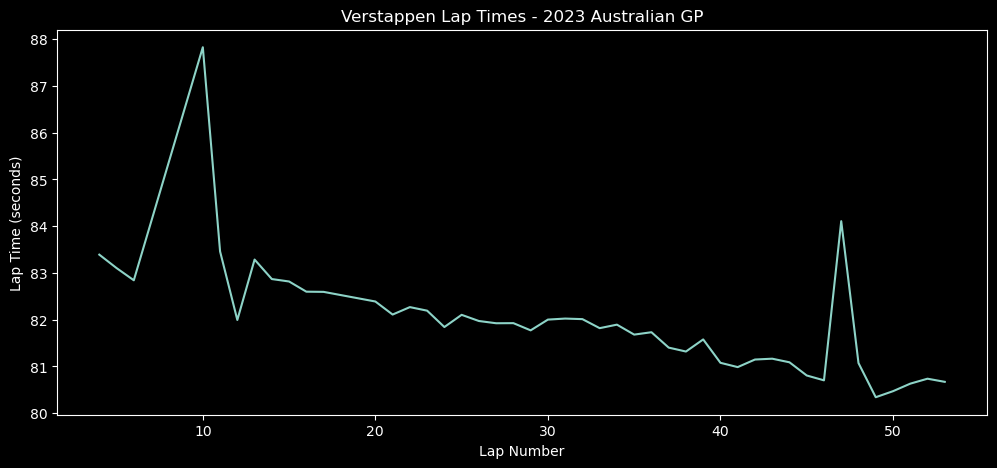

In [15]:
# fastf1 has built in methods - much cleaner
ver_laps = session.laps.pick_driver('VER').pick_accurate()
ver_laps['LapTimeSeconds'] = ver_laps['LapTime'].dt.total_seconds()

plt.figure(figsize=(12, 5))
plt.plot(ver_laps['LapNumber'], ver_laps['LapTimeSeconds'])
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Verstappen Lap Times - 2023 Australian GP')
plt.show()

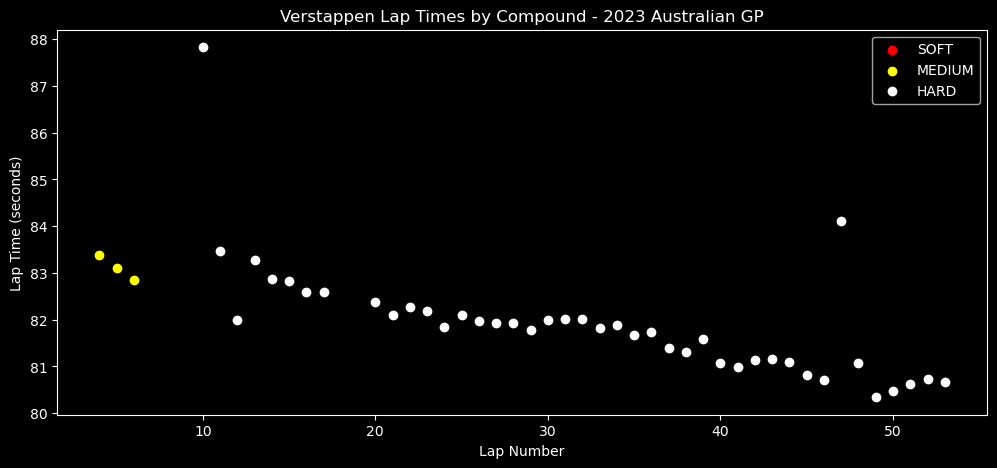

In [16]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 5))

soft_laps = ver_laps.pick_compounds('SOFT')
medium_laps = ver_laps.pick_compounds('MEDIUM')
hard_laps = ver_laps.pick_compounds('HARD')

ax.scatter(soft_laps['LapNumber'], soft_laps['LapTimeSeconds'], color='red', label='SOFT')
ax.scatter(medium_laps['LapNumber'], medium_laps['LapTimeSeconds'], color='yellow', label='MEDIUM')
ax.scatter(hard_laps['LapNumber'], hard_laps['LapTimeSeconds'], color='white', label='HARD')
ax.set_xlabel('Lap Number')
ax.set_ylabel('Lap Time (seconds)')
ax.set_title('Verstappen Lap Times by Compound - 2023 Australian GP')
ax.legend()
plt.show()

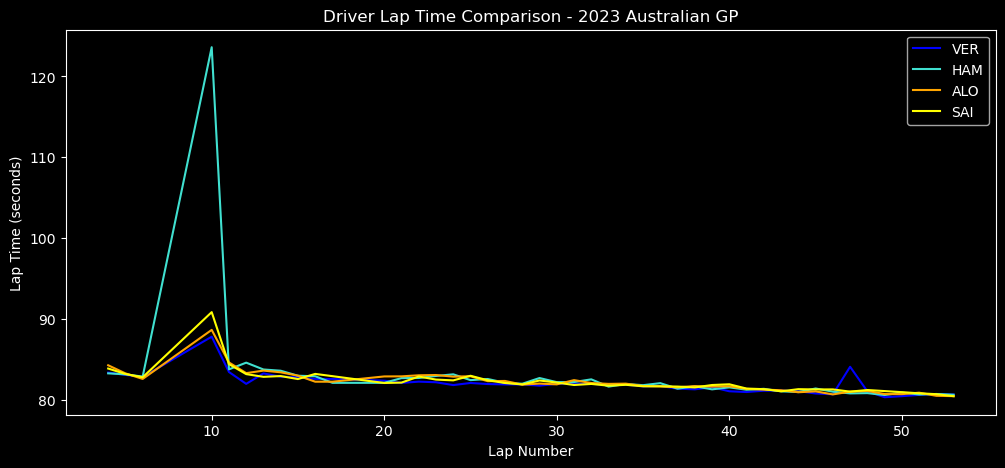

In [24]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 5))
driver_colors = {
    'VER': 'blue',
    'HAM': 'turquoise',
    'ALO': 'orange',
    'SAI': 'yellow'
}

for driver, color in driver_colors.items():
    driver_laps = session.laps.pick_drivers(driver).pick_accurate().copy()
    driver_laps['LapTimeSeconds'] = driver_laps['LapTime'].dt.total_seconds()
    ax.plot(driver_laps['LapNumber'], driver_laps['LapTimeSeconds'],
               label=driver, color=color)
ax.set_xlabel('Lap Number')
ax.set_ylabel('Lap Time (seconds)')
ax.set_title('Driver Lap Time Comparison - 2023 Australian GP')
ax.legend()

plt.show()

nan
0
